# WISE Animation — Steane [[7,1,3]] on WISE 3×3×2

Demonstrates the WISE trapped-ion compilation pipeline:
1. Build ideal stabiliser circuit (SteaneCode713)
2. Decompose to native MS + rotation gates
3. Map logical qubits → physical WISE grid positions
4. SAT-based WISE routing (reconfigurations + MS-gate scheduling)
5. Animated visualisation with ion transport & gate highlighting

## 0 · Imports & helpers

In [1]:
from __future__ import annotations
import os, sys
from collections import Counter
from types import SimpleNamespace

# Force complete module reload
_stale = [k for k in list(sys.modules.keys()) if 'qectostim' in k]
for _k in _stale:
    del sys.modules[_k]
print(f'Cleared {len(_stale)} cached qectostim modules')

import numpy as np
import stim

from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture, WISECompiler,
    TrappedIonExperiment, TrappedIonNoiseModel,
    display_architecture, animate_transport,
    QubitGate, MSGate, Measurement, GateSwap,
    Split, Merge, Move, JunctionCrossing,
    ParallelOperation,
)
from qectostim.codes.small.steane_713 import SteaneCode713

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
matplotlib.rcParams['animation.embed_limit'] = 120

def expand_reconfig_ops(ops):
    """Replace ReconfigurationPlanner objects with per-ion Move-like ops."""
    expanded = []
    for op in ops:
        movements = getattr(op, '_ion_movements', None)
        if type(op).__name__ == 'ReconfigurationPlanner' and movements:
            for ion_idx, src, tgt in movements:
                expanded.append(SimpleNamespace(
                    source_zone=src, target_zone=tgt,
                    qubits=(ion_idx,), ions=[], _ions=[],
                    metadata={'swap_type': 'RECONFIG'},
                ))
            expanded.append(SimpleNamespace(
                source_zone='__PASS_BOUNDARY__',
                target_zone='__PASS_BOUNDARY__',
                qubits=(-1,), ions=[], _ions=[],
            ))
        elif type(op).__name__ == 'ReconfigurationPlanner':
            pass
        else:
            expanded.append(op)
    return expanded

print('All imports OK')
print(f'  SteaneCode713: n={SteaneCode713().n}, k={SteaneCode713().k}')
assert hasattr(MSGate, 'qubitOperation'), 'MSGate missing qubitOperation!'
print('  MSGate.qubitOperation: OK')

Cleared 0 cached qectostim modules
All imports OK
  SteaneCode713: n=7, k=1
  MSGate.qubitOperation: OK


## 1 · Compile circuit & build mappings

In [2]:
wise_arch = WISEArchitecture(col_groups=3, rows=3, ions_per_segment=2)
code_wise = SteaneCode713()
comp_wise = WISECompiler(wise_arch)

print(f'Architecture : WISE 3x3x2  ({wise_arch.num_qubits} ions)')
print(f'Code         : Steane [[7,1,3]]  (n={code_wise.n}, k={code_wise.k})')

try:
    exp_wise = TrappedIonExperiment(
        code=code_wise, architecture=wise_arch,
        compiler=comp_wise,
        hardware_noise=TrappedIonNoiseModel(), rounds=1,
    )
    ideal_wise = exp_wise.build_ideal_circuit()
    print(f'Ideal circuit: {ideal_wise.num_qubits} qubits, '
          f'{len(ideal_wise)} instructions')

    n_data_wise = code_wise.n
    native_w = comp_wise.decompose_to_native(ideal_wise)
    mapped_w = comp_wise.map_qubits(native_w)
    routed_w = comp_wise.route(mapped_w)

    raw_wise_ops = routed_w.interleaved_operations()
    if not raw_wise_ops:
        raw_wise_ops = routed_w.routing_operations

    n_reconfig = sum(1 for o in raw_wise_ops
                     if type(o).__name__ == 'ReconfigurationPlanner')
    n_ms_raw = sum(1 for o in raw_wise_ops
                   if type(o).__name__ in ('MSGate', 'GateSwap'))
    print(f'Raw ops      : {len(raw_wise_ops)} total -- '
          f'{n_reconfig} reconfigs, {n_ms_raw} MS')

    wise_ops = expand_reconfig_ops(raw_wise_ops)
    n_ms = sum(1 for o in wise_ops
               if type(o).__name__ in ('MSGate', 'GateSwap'))
    print(f'Expanded ops : {len(wise_ops)} total, {n_ms} MS gates')

    # -- ion_idx_remap: QCCD-graph ion.idx -> grid position (0..17) --
    # The QCCD graph assigns non-contiguous node indices to ions
    # (1,2,4,5,7,8,...) while the animation uses 0-based grid slots.
    qi = wise_arch.qubit_ions
    wise_remap = {ion.idx: gp for gp, ion in enumerate(qi)}
    print(f'Ion remap    : {len(wise_remap)} entries  '
          f'(QCCD idx {min(wise_remap)}..{max(wise_remap)} '
          f'-> grid 0..{len(wise_remap)-1})')

    # -- Ion roles: Data / Measurement / Placeholder --
    p2l_w = mapped_w.mapping.physical_to_logical
    spectator_set = set(mapped_w.metadata.get('spectator_indices', []))
    print(f'Spectators   : {spectator_set}')
    wise_roles = {}
    for i in range(wise_arch.num_qubits):
        lq = p2l_w.get(i)
        if lq is not None and lq in spectator_set:
            wise_roles[i] = 'P'
        elif lq is not None and lq < n_data_wise:
            wise_roles[i] = 'D'
        elif lq is not None:
            wise_roles[i] = 'M'
        else:
            wise_roles[i] = 'P'
    print(f'Ion roles    : '
          f'{ {r: sum(1 for v in wise_roles.values() if v==r) for r in ("D","M","P")} }')

    # -- Physical-to-logical map for display labels --
    wise_p2l_display = {}
    for grid_pos in range(wise_arch.num_qubits):
        lq = p2l_w.get(grid_pos)
        if lq is not None and lq not in spectator_set:
            wise_p2l_display[grid_pos] = lq
    print(f'P2L display  : {wise_p2l_display}')

    # -- Verify MS gate pairing after remap --
    print('\n--- MS gate pairing check (first 5) ---')
    ms_ok = ms_bad = 0
    for op in wise_ops:
        if type(op).__name__ in ('MSGate', 'GateSwap'):
            ions = getattr(op, 'ions', None) or getattr(op, '_ions', [])
            ion_idxs = [getattr(ion, 'idx', -1) for ion in ions]
            grid_idxs = [wise_remap.get(idx, idx) for idx in ion_idxs]
            logicals = [p2l_w.get(gp, '?') for gp in grid_idxs]
            roles = []
            for lq in logicals:
                if isinstance(lq, int) and lq in spectator_set: roles.append('S')
                elif isinstance(lq, int) and lq < n_data_wise: roles.append('D')
                elif isinstance(lq, int): roles.append('A')
                else: roles.append('?')
            if len(roles) == 2 and roles[0] != roles[1] and 'S' not in roles:
                ms_ok += 1
            else:
                ms_bad += 1
            if ms_ok + ms_bad <= 5:
                print(f'  ion.idx={ion_idxs} -> grid={grid_idxs} -> '
                      f'logical={logicals} [{"-".join(roles)}]')
    print(f'MS gates: {ms_ok} D-A (correct), {ms_bad} other')

    stim_wise = getattr(native_w, 'stim_source', None) or ideal_wise
    print('\nCompilation succeeded')

except Exception as e:
    import traceback; traceback.print_exc()
    print(f'Compilation error: {type(e).__name__}: {e}')
    wise_ops = []
    wise_roles = {i: 'D' for i in range(7)}
    wise_roles.update({i: 'P' for i in range(7, wise_arch.num_qubits)})
    wise_remap = None
    wise_p2l_display = None
    stim_wise = ideal_wise if 'ideal_wise' in dir() else None

Architecture : WISE 3x3x2  (18 ions)
Code         : Steane [[7,1,3]]  (n=7, k=1)
Compilation error: ImportError: cannot import name 'QECMetadata' from 'qectostim.experiments.hardware_simulation.core.pipeline' (/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/core/pipeline.py)


Traceback (most recent call last):
  File "/var/folders/wb/b8rfjwj12jn7gld5g0b3c2x80000gn/T/ipykernel_88900/508257083.py", line 14, in <module>
    ideal_wise = exp_wise.build_ideal_circuit()
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/experiments.py", line 424, in build_ideal_circuit
    self._ideal_circuit = self._build_memory_circuit()
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/experiments.py", line 453, in _build_memory_circuit
    return self._build_css_memory_circuit()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_

## 2 · WISE Animation

Static display + animated HTML5 player with ion transport & MS-gate highlighting.

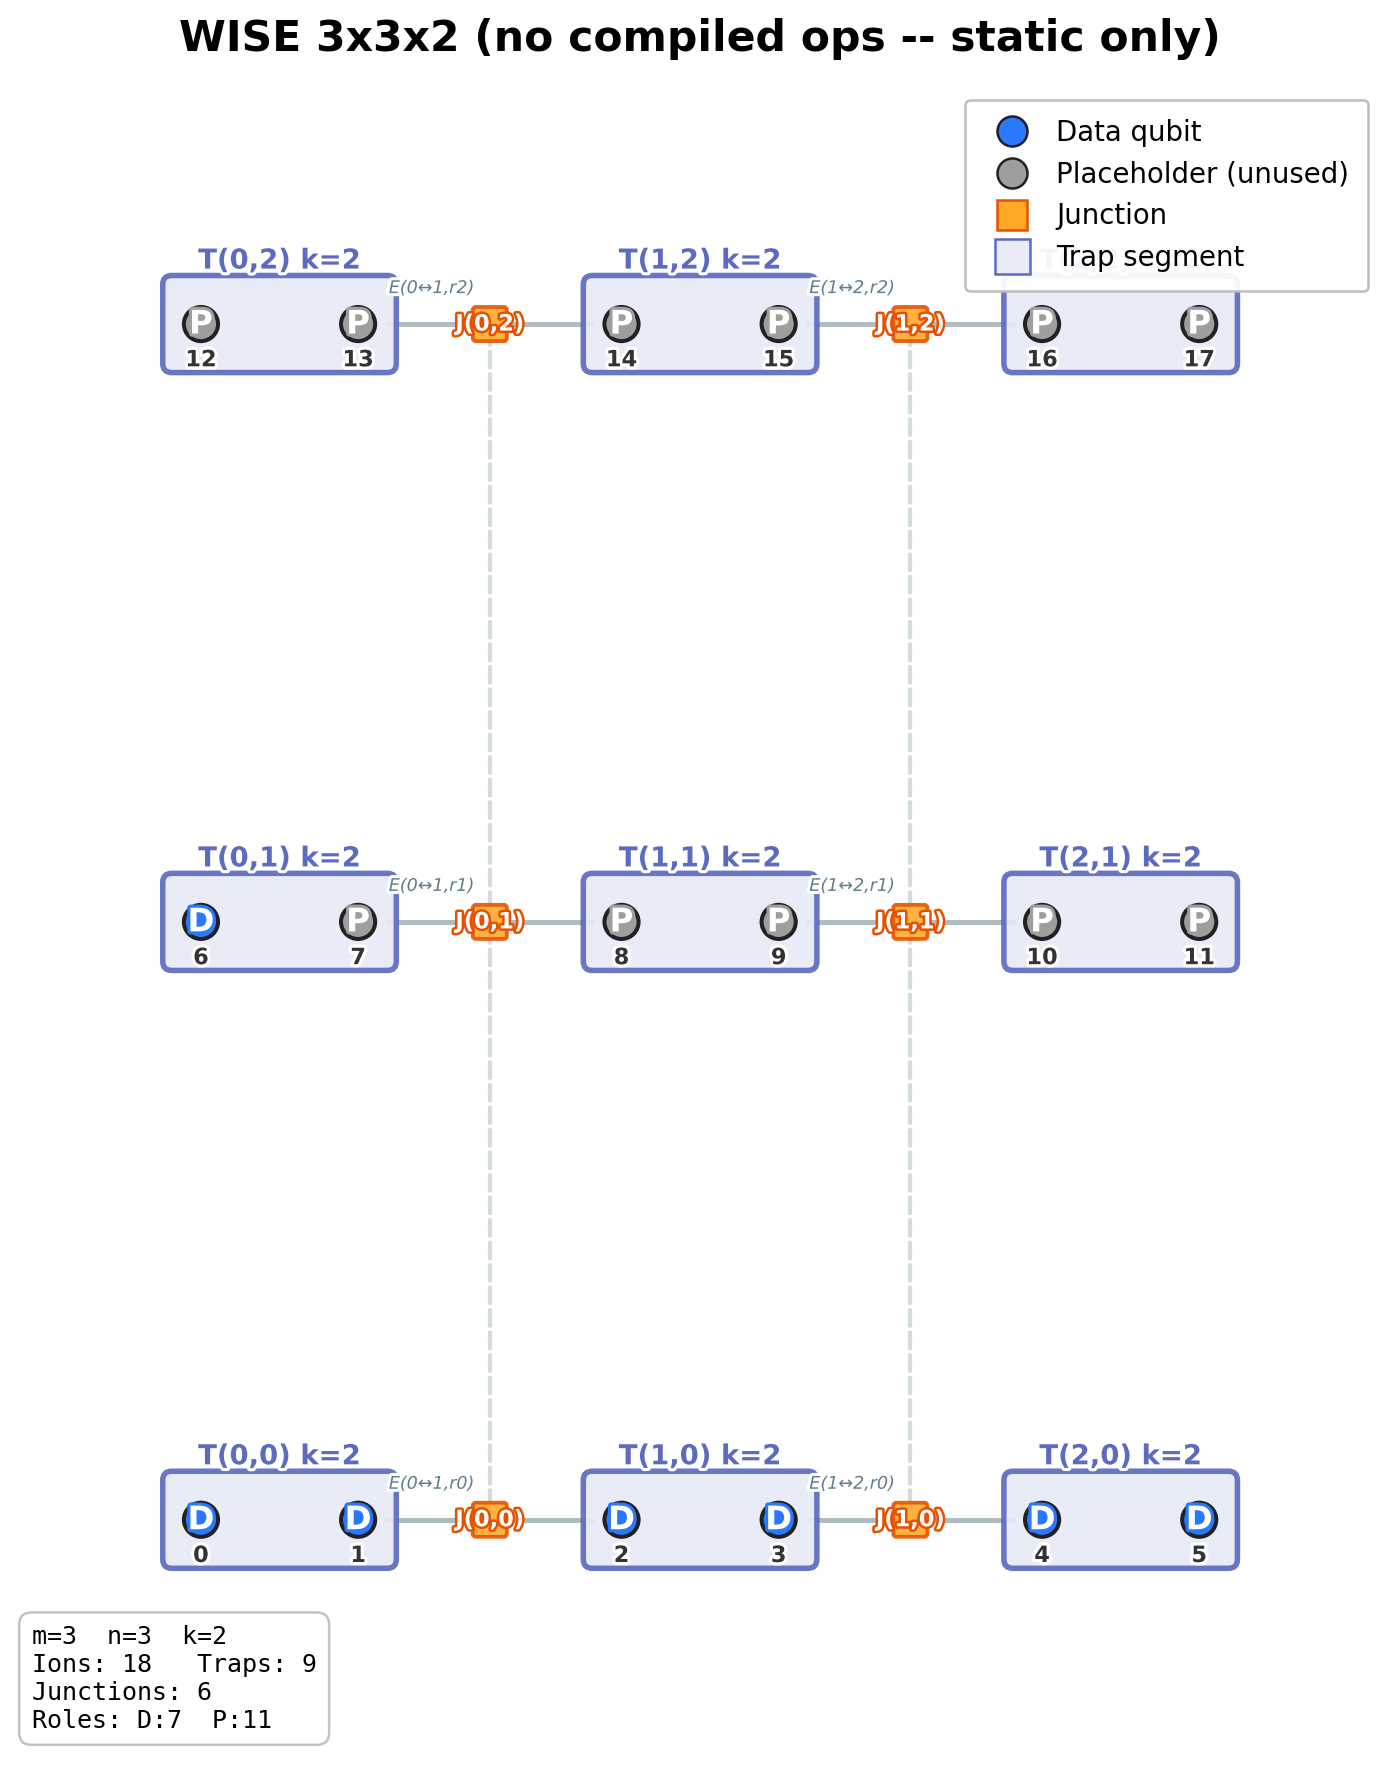

No compiled ops -- showing static architecture only


In [3]:
if wise_ops:
    # Static first frame
    fig_w, ax_w = display_architecture(
        wise_arch,
        title=f'Steane [[7,1,3]] on WISE 3x3x2 -- {n_reconfig} reconfigs, {n_ms} MS',
        ion_roles=wise_roles, show_labels=True)
    plt.show()

    # Build animation (reduced frames + lower DPI for smaller output)
    try:
        anim_wise = animate_transport(
            wise_arch, wise_ops, interval=200, show_labels=True,
            ion_roles=wise_roles, interp_frames=3,
            gate_hold_frames=3, stim_circuit=stim_wise,
            ion_idx_remap=wise_remap,
            physical_to_logical=wise_p2l_display,
        )

        html_wise = anim_wise.to_jshtml(default_mode='loop')
        display(HTML(html_wise))
        print(f'WISE animation: {len(html_wise)//1024} KB HTML')
        plt.close(anim_wise._fig)

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'WISE animation error: {type(e).__name__}: {e}')
else:
    fig_w, ax_w = display_architecture(
        wise_arch,
        title='WISE 3x3x2 (no compiled ops -- static only)',
        ion_roles=wise_roles, show_labels=True)
    plt.show()
    print('No compiled ops -- showing static architecture only')